# Predicting the Helpfulness and Harmlessness of LLM Responses

This project predicts, from features of a response alone, whether a human would prefer it as more **helpful**
and more **harmless** than an alternative — the signal at the heart of the reward models used to align modern
AI assistants.

It runs the full pipeline on real human-preference data: exploratory analysis, then a baseline tuned across
three model families that plateaus near **0.61 ROC-AUC (helpfulness)** and **0.585 (harmlessness)**, and then
an improved **pairwise** formulation that breaks that plateau — reaching **0.69** and **0.71** respectively,
using only fast, interpretable models (no deep learning). The gain comes from reframing the problem, not from a
heavier model.

The notebook is self-contained and downloads its data automatically via the Hugging Face `datasets` library;
no manual download is needed.

## 1. Business understanding and research question

When an AI assistant answers a question, two things matter: is the answer **helpful** (does it address what
the user asked?) and is it **harmless** (does it avoid unsafe, misleading, or inappropriate content?).
Judging this at scale currently relies on slow, expensive human review of responses one at a time.

**Research question.** Given a conversational prompt and a candidate response, can a machine-learning system
predict whether that response is the one a human would prefer — separately for **helpfulness** and
**harmlessness** — and identify which features of the response drive that prediction, without a human label at
the moment of judgment?

A fast, explainable model that scores both qualities would be directly useful as a pre-filter in production
AI-evaluation pipelines, and — unlike a black box — would let a reviewer see *why* a response was flagged.

## 2. Data

[**Anthropic HH-RLHF**](https://huggingface.co/datasets/Anthropic/hh-rlhf) (Helpful and Harmless RLHF, MIT
license) is a set of ~161,000 human preference pairs: a conversational prompt plus two candidate responses,
with a human annotator's choice of the better one. We use the `helpful-base` and `harmless-base` subsets and
keep the dataset's original train/test split.

Crucially, the data is made of **head-to-head pairs**: the two responses in a record answer the *same* prompt.
We load it **pair-aware** (one row per pair, holding both responses and a `pair_id`), which lets us later model
the task either response-by-response or as a direct comparison.

In [1]:
import logging
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import disable_progress_bars, load_dataset
from datasets.utils import logging as hf_logging
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay, accuracy_score, confusion_matrix, f1_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

hf_logging.set_verbosity_error()                              # silence dataset-loading logs
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)  # silence Hub request warnings
disable_progress_bars()                                       # clean output, no progress bars
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
SUBSETS = ["helpful-base", "harmless-base"]

In [2]:
def split_conversation(text):
    """Split a transcript into (prompt, final_assistant_response)."""
    idx = text.rfind("\n\nAssistant:")
    if idx == -1:
        return text.strip(), ""
    return text[:idx].strip(), text[idx + len("\n\nAssistant:"):].strip()


def load_pairs(subset_name):
    """Load a HH-RLHF subset as one row per preference pair (chosen + rejected share a prompt)."""
    ds = load_dataset("Anthropic/hh-rlhf", data_dir=subset_name)
    rows = []
    pid = 0
    for split in ["train", "test"]:
        for rec in ds[split]:
            prompt, chosen = split_conversation(rec["chosen"])
            _, rejected = split_conversation(rec["rejected"])  # same prompt as chosen
            rows.append({"subset": subset_name, "split": split, "pair_id": f"{subset_name}-{pid}",
                         "prompt": prompt, "chosen": chosen, "rejected": rejected})
            pid += 1
    return pd.DataFrame(rows)


raw = {name: load_pairs(name) for name in SUBSETS}
for name, df in raw.items():
    print(f"{name}: {len(df):,} preference pairs")
raw["helpful-base"].head(3)[["split", "pair_id", "prompt", "chosen", "rejected"]]

helpful-base: 46,189 preference pairs
harmless-base: 44,849 preference pairs


,split,pair_id,prompt,chosen,rejected
0,train,helpful-base-0,"Human: Hi, I want to learn to play horseshoes....",A horseshoe is usually made out of metal and i...,Horseshoes are either metal or plastic discs. ...
1,train,helpful-base-1,Human: How do I teach kids to meditate?\n\nAss...,"Kids are great at fidgeting, so let’s make sur...","Yeah, definitely. What works for you personall..."
2,train,helpful-base-2,Human: Can you tell me the steps for getting a...,"At the marina level, there’s usually the renta...","Oh, I’m afraid I’m not very familiar with thes..."


## 3. Data cleaning

We check for empty responses and duplicate pairs, then drop them. As in any text dataset, a small number of
records fail to parse a final response; these and exact-duplicate pairs are removed. Repeated *short* responses
(e.g. the same refusal phrase) are kept — they reflect real recurring model behavior, not corrupted data.

In [3]:
def clean_pairs(df):
    empty = (df["chosen"].str.strip() == "") | (df["rejected"].str.strip() == "")
    dupes = df.duplicated(subset=["prompt", "chosen", "rejected"])
    print(f"  {df['subset'].iloc[0]}: {empty.sum()} pairs with an empty response, "
          f"{dupes.sum()} exact-duplicate pairs -> dropped")
    return df[~empty].drop_duplicates(subset=["prompt", "chosen", "rejected"]).reset_index(drop=True)


print("Cleaning:")
pairs = {name: clean_pairs(df) for name, df in raw.items()}
for name, df in pairs.items():
    n_tr, n_te = (df.split == "train").sum(), (df.split == "test").sum()
    print(f"{name}: {len(df):,} pairs after cleaning ({n_tr:,} train / {n_te:,} test)")

Cleaning:
  helpful-base: 56 pairs with an empty response, 0 exact-duplicate pairs -> dropped
  harmless-base: 55 pairs with an empty response, 0 exact-duplicate pairs -> dropped
helpful-base: 46,133 pairs after cleaning (43,783 train / 2,350 test)
harmless-base: 44,794 pairs after cleaning (42,486 train / 2,308 test)


## 4. Feature engineering

For each response we derive interpretable features in three groups:

- **Surface** (11) — length (characters, words, sentences), average word length, vocabulary richness, a
  hedging-word ratio, a refusal-phrase flag, question/exclamation counts, response-to-prompt length ratio, and
  an approximate reading-ease score.
- **Structure** (6) — code blocks, list items, URLs, digit ratio, capitalization ratio, second-person address.
- **Relevance** (2) — word overlap between the prompt and the response (Jaccard overlap, keyword coverage):
  a direct measure of whether the response actually addresses the question.

In [4]:
HEDGE_WORDS = [
    "perhaps", "maybe", "might", "possibly", "i think", "i believe", "could be", "seems",
    "appears", "i guess", "probably", "i\'m not sure", "i am not sure", "it\'s possible", "likely"]
REFUSAL_PATTERN = re.compile(
    r"\b(i cannot|i can\'t|i won\'t|i will not|i\'m sorry, but|i am sorry, but|as an ai|"
    r"i\'m not able to|i am not able to|i must decline|i\'m unable to|i am unable to)\b", re.I)
URL_PATTERN = re.compile(r"https?://|www\.")
WORD_RE = re.compile(r"[a-z\']+")
STOPWORDS = set("the a an and or of to in is are was were be been i you it this that for on with as at your "
                "my our their his her its not no do does did can could would should will".split())


def count_syllables(word):
    n = len(re.findall(r"[aeiouy]+", word.lower()))
    if word.lower().endswith("e") and n > 1:
        n -= 1
    return max(n, 1)


def flesch_reading_ease(text, word_count, sentence_count):
    words = re.findall(r"[a-zA-Z\']+", text)
    if not words or sentence_count == 0:
        return 0.0
    syllables = sum(count_syllables(w) for w in words)
    return 206.835 - 1.015 * (word_count / sentence_count) - 84.6 * (syllables / word_count)


def response_features(response, prompt):
    f = {}
    char_count = len(response)
    word_count = max(len(response.split()), 1)
    sentence_count = max(len(re.findall(r"[.!?]+", response)), 1)
    lowered, tokens = response.lower(), response.split()
    # surface
    f["char_count"] = char_count
    f["word_count"] = word_count
    f["sentence_count"] = sentence_count
    f["avg_word_length"] = char_count / word_count
    f["unique_word_ratio"] = len(set(t.lower() for t in tokens)) / max(len(tokens), 1)
    f["hedge_word_ratio"] = sum(lowered.count(h) for h in HEDGE_WORDS) / word_count
    f["is_refusal"] = int(bool(REFUSAL_PATTERN.search(response)))
    f["question_count"] = response.count("?")
    f["exclamation_count"] = response.count("!")
    f["response_prompt_ratio"] = char_count / max(len(prompt), 1)
    f["reading_ease"] = flesch_reading_ease(response, word_count, sentence_count)
    # structure
    f["has_code"] = int("```" in response)
    f["n_list_items"] = len(re.findall(r"(?m)^\s*([-*]|\d+\.)\s", response))
    f["n_urls"] = len(URL_PATTERN.findall(response))
    f["digit_ratio"] = sum(ch.isdigit() for ch in response) / max(char_count, 1)
    f["caps_ratio"] = sum(ch.isupper() for ch in response) / max(char_count, 1)
    f["second_person"] = lowered.count("you ") + lowered.count("your ")
    # relevance
    p_tok = set(WORD_RE.findall(prompt.lower())) - STOPWORDS
    r_tok = set(WORD_RE.findall(lowered)) - STOPWORDS
    shared = len(p_tok & r_tok)
    f["jaccard_overlap"] = shared / max(len(p_tok | r_tok), 1)
    f["keyword_coverage"] = shared / max(len(p_tok), 1)
    return f


BASE_FEATURES = ["char_count", "word_count", "sentence_count", "avg_word_length", "unique_word_ratio",
                 "hedge_word_ratio", "is_refusal", "question_count", "exclamation_count",
                 "response_prompt_ratio", "reading_ease"]
NEW_FEATURES = ["has_code", "n_list_items", "n_urls", "digit_ratio", "caps_ratio", "second_person",
                "jaccard_overlap", "keyword_coverage"]
ALL_FEATURES = BASE_FEATURES + NEW_FEATURES


def feature_frames(df):
    chosen = pd.DataFrame([response_features(r.chosen, r.prompt) for r in df.itertuples()], index=df.index)
    rejected = pd.DataFrame([response_features(r.rejected, r.prompt) for r in df.itertuples()], index=df.index)
    return chosen, rejected


feat_chosen, feat_rejected = {}, {}
for name in SUBSETS:
    feat_chosen[name], feat_rejected[name] = feature_frames(pairs[name])


def pointwise_frame(name):
    """One row per response (chosen=1, rejected=0) for EDA and pointwise modeling."""
    df = pairs[name]
    a = feat_chosen[name].copy(); a["label"] = 1
    b = feat_rejected[name].copy(); b["label"] = 0
    for part in (a, b):
        part["subset"] = df["subset"].values
        part["split"] = df["split"].values
    return pd.concat([a, b], ignore_index=True)


data = pd.concat([pointwise_frame(n) for n in SUBSETS], ignore_index=True)
print(f"Per-response rows for EDA/pointwise modeling: {len(data):,}")
print(f"Features: {len(BASE_FEATURES)} surface + {len(NEW_FEATURES)} structure/relevance = {len(ALL_FEATURES)}")
data[["subset", "split", "label"] + ALL_FEATURES].head()

Per-response rows for EDA/pointwise modeling: 181,854
Features: 11 surface + 8 structure/relevance = 19


,subset,split,label,char_count,word_count,sentence_count,avg_word_length,unique_word_ratio,hedge_word_ratio,is_refusal,question_count,exclamation_count,response_prompt_ratio,reading_ease,has_code,n_list_items,n_urls,digit_ratio,caps_ratio,second_person,jaccard_overlap,keyword_coverage
0,helpful-base,train,1,246,50,4,4.920000,0.760000,0.000000,0,0,0,0.964706,90.935500,0,0,0,0.024390,0.012195,0,0.043478,0.086957
1,helpful-base,train,1,82,15,1,5.466667,1.000000,0.000000,0,0,0,0.181015,73.170000,0,0,0,0.000000,0.012195,0,0.109091,0.125000
2,helpful-base,train,1,329,61,2,5.393443,0.704918,0.016393,0,0,0,0.625475,51.057828,0,0,0,0.000000,0.009119,3,0.238806,0.307692
3,helpful-base,train,1,124,24,1,5.166667,0.708333,0.000000,0,0,0,2.339623,69.675000,0,0,0,0.000000,0.008065,2,0.125000,0.250000
4,helpful-base,train,1,182,34,1,5.352941,0.852941,0.029412,0,0,0,0.551515,57.866176,0,0,0,0.005495,0.060440,0,0.122449,0.166667


## 5. Exploratory data analysis

### 5.1 Class balance

In [5]:
balance = data.groupby(["subset", "label"]).size().unstack()
balance.columns = ["rejected", "chosen"]
print(balance)
print("\nClasses are balanced by construction: every pair contributes exactly one chosen and one rejected "
      "response, so a coin-flip baseline is exactly 50%.")

               rejected  chosen
subset                         
harmless-base     44794   44794
helpful-base      46133   46133

Classes are balanced by construction: every pair contributes exactly one chosen and one rejected response, so a coin-flip baseline is exactly 50%.


### 5.2 Response length: chosen vs. rejected

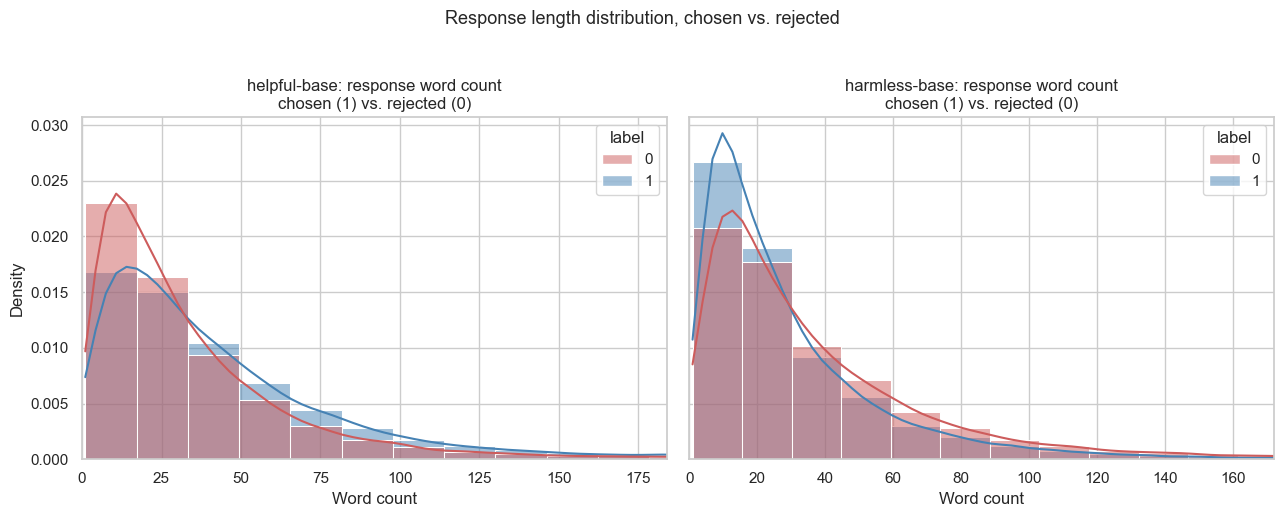

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, name in zip(axes, SUBSETS):
    sub = data[data["subset"] == name]
    sns.histplot(data=sub, x="word_count", hue="label", bins=40, kde=True, stat="density",
                 common_norm=False, ax=ax, palette={0: "indianred", 1: "steelblue"})
    ax.set_xlim(0, sub["word_count"].quantile(0.99))
    ax.set_title(f"{name}: response word count\nchosen (1) vs. rejected (0)")
    ax.set_xlabel("Word count"); ax.set_ylabel("Density")
fig.suptitle("Response length distribution, chosen vs. rejected", y=1.03, fontsize=13)
fig.tight_layout(); plt.show()

**What this shows:** in `helpful-base`, chosen responses skew slightly longer than rejected ones; in
`harmless-base` the effect is weaker and, if anything, reversed — an early hint that the two objectives reward
different writing.

### 5.3 Hedging language and refusals by outcome

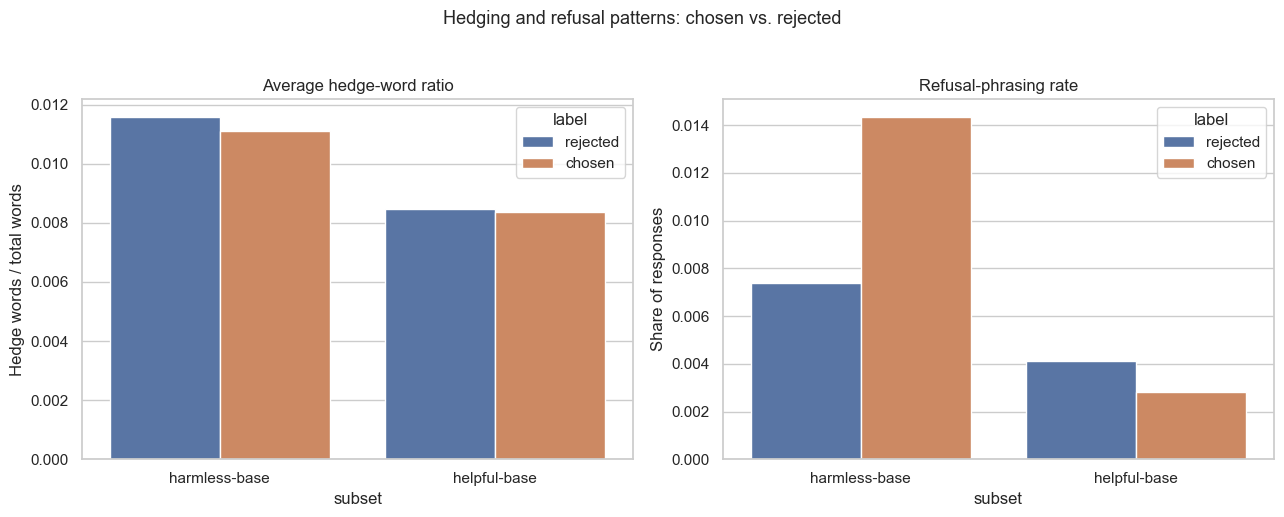

,subset,label,avg_hedge_word_ratio,refusal_rate
0,harmless-base,rejected,0.011596,0.007367
1,harmless-base,chosen,0.011108,0.014355
2,helpful-base,rejected,0.008463,0.004097
3,helpful-base,chosen,0.008378,0.002818


In [7]:
summary = (data.groupby(["subset", "label"])[["hedge_word_ratio", "is_refusal"]].mean()
           .rename(columns={"hedge_word_ratio": "avg_hedge_word_ratio", "is_refusal": "refusal_rate"})
           .reset_index())
summary["label"] = summary["label"].map({0: "rejected", 1: "chosen"})
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=summary, x="subset", y="avg_hedge_word_ratio", hue="label", ax=axes[0])
axes[0].set_title("Average hedge-word ratio"); axes[0].set_ylabel("Hedge words / total words")
sns.barplot(data=summary, x="subset", y="refusal_rate", hue="label", ax=axes[1])
axes[1].set_title("Refusal-phrasing rate"); axes[1].set_ylabel("Share of responses")
fig.suptitle("Hedging and refusal patterns: chosen vs. rejected", y=1.03, fontsize=13)
fig.tight_layout(); plt.show()
summary

**What this shows:** in `harmless-base`, chosen responses use refusal phrasing noticeably more often than
rejected ones — annotators reward safe refusals to sensitive prompts. The pattern is much weaker for
`helpful-base`.

### 5.4 Correlation between numeric features

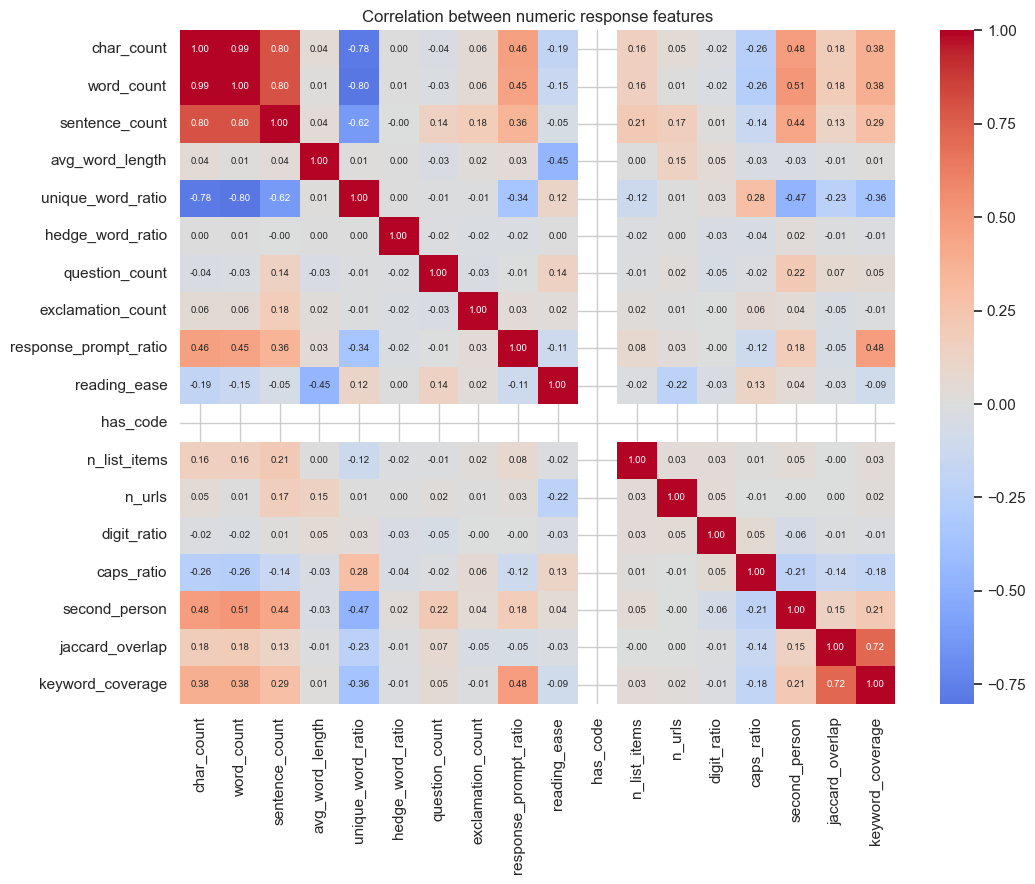

In [8]:
numeric_cols = [c for c in ALL_FEATURES if c != "is_refusal"]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation between numeric response features")
plt.tight_layout(); plt.show()

**What this shows:** the length features (`char_count`, `word_count`, `sentence_count`) are highly
correlated with one another, as expected. Tree-based models handle this redundancy automatically; for the
linear models we standardize features and read coefficients with the correlation in mind.

## 6. Modeling — Part 1: baseline and tuned model comparison (pointwise)

We first take the natural approach: treat each response on its own and predict whether it was the chosen one.
Three models are trained and tuned **separately for each subset**:

- **Logistic Regression** — an interpretable linear baseline (on standardized features).
- **Random Forest** — an ensemble of trees that captures nonlinear feature interactions.
- **XGBoost** — gradient-boosted trees, typically the strongest off-the-shelf model for tabular features.

Each is tuned with **`GridSearchCV` (5-fold cross-validation)**, selecting hyperparameters by cross-validated
accuracy rather than a single fixed configuration.

**Evaluation metric.** Because classes are perfectly balanced, **accuracy** is a fair, easy-to-explain headline
(chance = 50%). We report **ROC-AUC** alongside it — the metric most aligned with the use case, since it
measures ranking quality rather than performance at one fixed threshold — and **F1** as a sanity check.

In [9]:
POINTWISE_MODELS = {
    "Logistic Regression": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                            {"logisticregression__C": [0.1, 1, 10]}),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=-1),
                      {"n_estimators": [200], "max_depth": [12, None]}),
    "XGBoost": (XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=42, n_jobs=-1),
                {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05]}),
}


def run_pointwise(name):
    sub = data[data["subset"] == name]
    train, test = sub[sub["split"] == "train"], sub[sub["split"] == "test"]
    Xtr, ytr = train[BASE_FEATURES], train["label"]
    Xte, yte = test[BASE_FEATURES], test["label"]
    out = {}
    for model_name, (estimator, grid) in POINTWISE_MODELS.items():
        gs = GridSearchCV(estimator, grid, cv=5, scoring="accuracy", n_jobs=1).fit(Xtr, ytr)
        proba = gs.predict_proba(Xte)[:, 1]
        preds = (proba >= 0.5).astype(int)
        out[model_name] = {"cv_accuracy": gs.best_score_, "test_accuracy": accuracy_score(yte, preds),
                           "test_roc_auc": roc_auc_score(yte, proba), "test_f1": f1_score(yte, preds),
                           "estimator": gs.best_estimator_, "yte": yte, "proba": proba, "preds": preds}
    return out


pointwise = {name: run_pointwise(name) for name in SUBSETS}
rows = [{"subset": s, "model": m, "cv_accuracy": r["cv_accuracy"], "test_accuracy": r["test_accuracy"],
         "test_roc_auc": r["test_roc_auc"], "test_f1": r["test_f1"]}
        for s, models in pointwise.items() for m, r in models.items()]
pointwise_df = pd.DataFrame(rows)
pointwise_df.round(3)

,subset,model,cv_accuracy,test_accuracy,test_roc_auc,test_f1
0,helpful-base,Logistic Regression,0.562,0.567,0.598,0.515
1,helpful-base,Random Forest,0.571,0.580,0.611,0.579
2,helpful-base,XGBoost,0.574,0.580,0.614,0.580
3,harmless-base,Logistic Regression,0.555,0.560,0.571,0.605
4,harmless-base,Random Forest,0.560,0.566,0.585,0.580
5,harmless-base,XGBoost,0.562,0.564,0.583,0.575


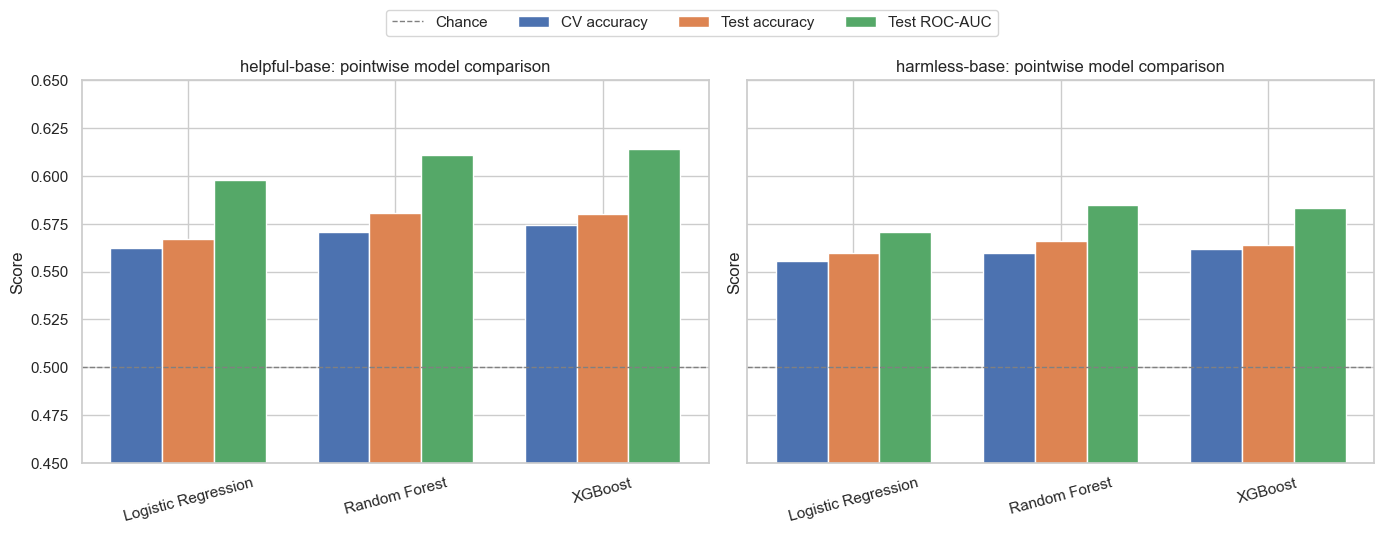

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name in zip(axes, SUBSETS):
    sub = pointwise_df[pointwise_df["subset"] == name]
    x = np.arange(len(sub)); w = 0.25
    ax.bar(x - w, sub["cv_accuracy"], w, label="CV accuracy")
    ax.bar(x, sub["test_accuracy"], w, label="Test accuracy")
    ax.bar(x + w, sub["test_roc_auc"], w, label="Test ROC-AUC")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance")
    ax.set_xticks(x); ax.set_xticklabels(sub["model"], rotation=15)
    ax.set_title(f"{name}: pointwise model comparison"); ax.set_ylabel("Score"); ax.set_ylim(0.45, 0.65)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout(); plt.show()

**What this shows:** cross-validated and test scores are close for every model (no overfitting), and the
three models land within a couple of points of each other. Tree-based models edge out the linear baseline, but
**every model plateaus around 0.61 ROC-AUC (helpful) / 0.585 (harmless)** — no algorithm choice breaks through.
This plateau motivates Part 2.

### 6.1 Best model detail: XGBoost confusion matrix, ROC, and feature importance

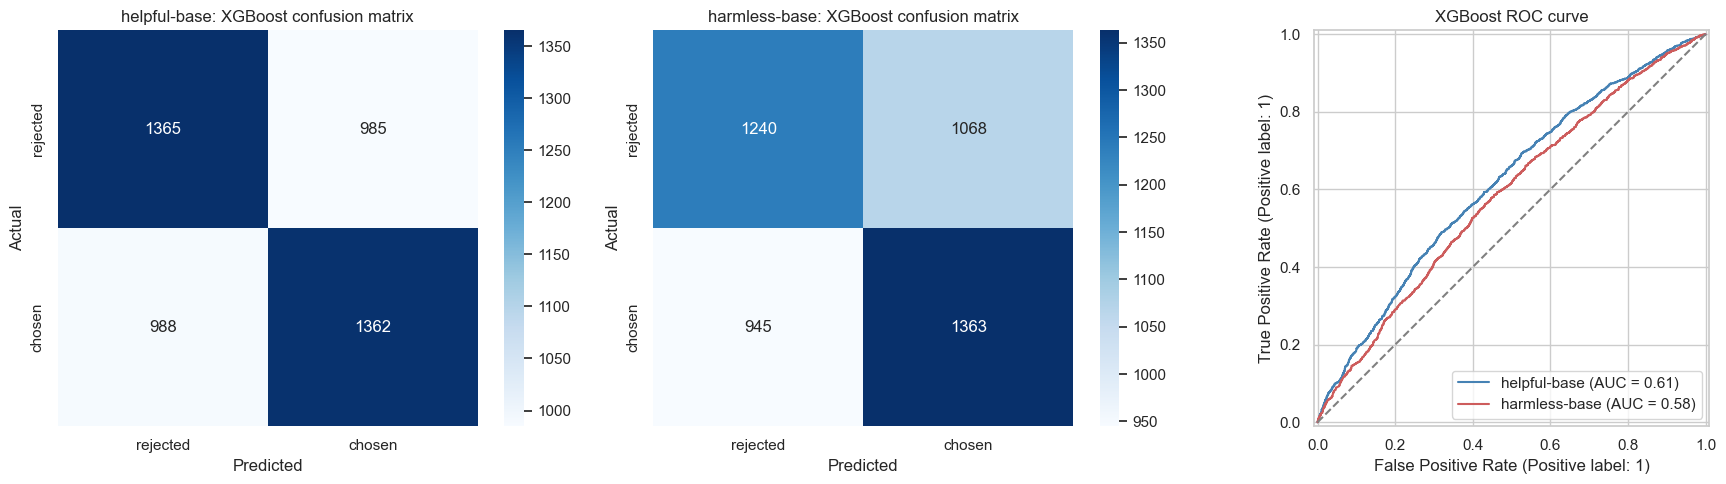

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes[:2], SUBSETS):
    r = pointwise[name]["XGBoost"]
    sns.heatmap(confusion_matrix(r["yte"], r["preds"]), annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["rejected", "chosen"], yticklabels=["rejected", "chosen"])
    ax.set_title(f"{name}: XGBoost confusion matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for name, color in [("helpful-base", "steelblue"), ("harmless-base", "indianred")]:
    r = pointwise[name]["XGBoost"]
    RocCurveDisplay.from_predictions(r["yte"], r["proba"], name=name, color=color, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "--", color="gray"); axes[2].set_title("XGBoost ROC curve")
fig.tight_layout(); plt.show()

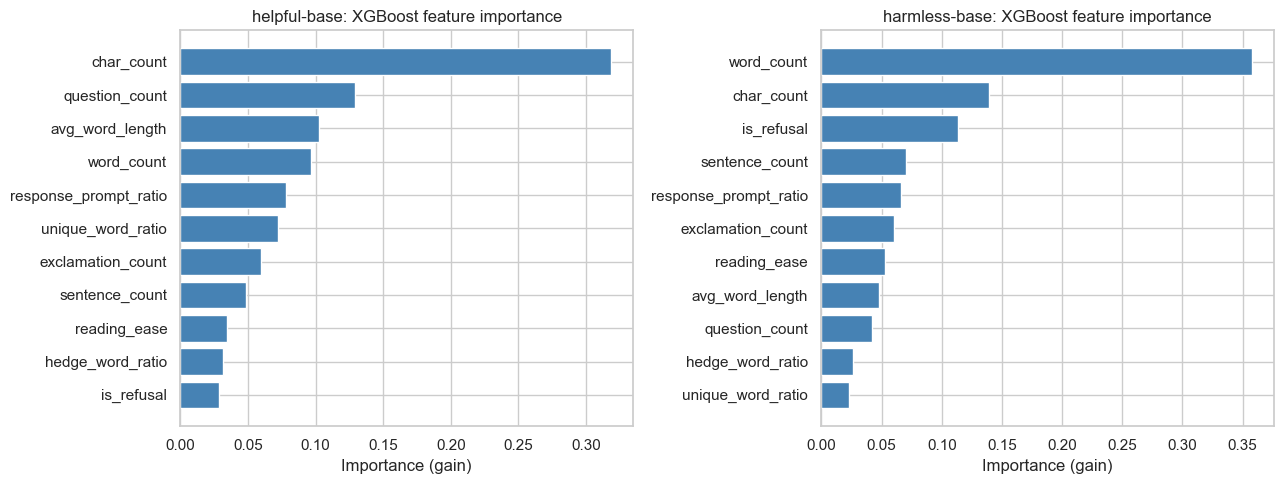

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, SUBSETS):
    imp = pd.Series(pointwise[name]["XGBoost"]["estimator"].feature_importances_,
                    index=BASE_FEATURES).sort_values()
    ax.barh(imp.index, imp.values, color="steelblue")
    ax.set_title(f"{name}: XGBoost feature importance"); ax.set_xlabel("Importance (gain)")
fig.tight_layout(); plt.show()

**What this shows:** for `harmless-base`, the top features are `is_refusal` and length — refusals help,
length hurts. For `helpful-base`, length and vocabulary features lead. The two objectives clearly weight
features differently, but a pointwise model can only express weak *global* tendencies, which is why it
plateaus.

## 7. Modeling — Part 2: a better problem formulation (pairwise preference learning)

The plateau in Part 1 is not a model-power problem — it is a **framing** problem. A feature like
`word_count = 200` is meaningless in isolation: the same length is "chosen" for one prompt and "rejected" for
another, depending on what the prompt needed. Judging each response alone discards the prompt-matched pairing
where the signal lives.

The fix is to model the task the way it was labelled — as a **preference between two responses to the same
prompt**. For each pair we learn from the *difference* of the two responses' features
(`feature(chosen) − feature(rejected)`), the way real reward models (Bradley–Terry models) are trained. We use
each pair symmetrically — as `(d, 1)` and `(−d, 0)` — and tune with **`GroupKFold`** grouped by `pair_id`, so a
pair's two halves never leak across cross-validation folds. Every model — including the Part-1 pointwise model —
is then scored on the **same** test task: for each test pair, does it rank the chosen response above the
rejected one?

*Note on the symmetric design and significance:* for logistic regression, learning from feature differences
this way is exactly a **Bradley–Terry** preference model; for the tree models it is a close, well-behaved
approximation. Each subset's test set holds ~2,300 pairs, so the differences reported below are comfortably
larger than sampling noise (quantified with bootstrap confidence intervals in Section 7.4).

In [13]:
def masks(name):
    s = pairs[name]["split"]
    return (s == "train").values, (s == "test").values


def pairwise_design(ch, rj, cols):
    d = ch[cols].values - rj[cols].values
    X = np.vstack([d, -d]); y = np.r_[np.ones(len(d)), np.zeros(len(d))]
    groups = np.r_[np.arange(len(d)), np.arange(len(d))]
    return X, y, groups


def pairwise_scores(model, ch, rj, cols):
    d = ch[cols].values - rj[cols].values
    acc = accuracy_score(np.ones(len(d)), (model.predict_proba(d)[:, 1] >= 0.5).astype(int))
    proba_both = model.predict_proba(np.vstack([d, -d]))[:, 1]
    return acc, roc_auc_score(np.r_[np.ones(len(d)), np.zeros(len(d))], proba_both)


def pointwise_as_ranking(name):
    """Score the Part-1 pointwise XGBoost on test pairs, for an apples-to-apples comparison."""
    tr, te = masks(name)
    model = pointwise[name]["XGBoost"]["estimator"]
    s_ch = model.predict_proba(feat_chosen[name][te][BASE_FEATURES])[:, 1]
    s_rj = model.predict_proba(feat_rejected[name][te][BASE_FEATURES])[:, 1]
    acc = (s_ch > s_rj).mean()
    auc = roc_auc_score(np.r_[np.ones(len(s_ch)), np.zeros(len(s_rj))], np.r_[s_ch, s_rj])
    return acc, auc


PAIR_MODELS = {
    "Logistic Regression": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, fit_intercept=False)),
                            {"logisticregression__C": [0.1, 1, 10]}),
    "XGBoost": (XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=42, n_jobs=-1),
                {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05]}),
}
cv = GroupKFold(n_splits=5)
records, pairwise_fitted = [], {name: {} for name in SUBSETS}


def tune_pairwise(name, cols, label, models=PAIR_MODELS):
    tr, _ = masks(name)
    ch_tr, rj_tr = feat_chosen[name][tr], feat_rejected[name][tr]
    _, te = masks(name)
    ch_te, rj_te = feat_chosen[name][te], feat_rejected[name][te]
    X, y, groups = pairwise_design(ch_tr, rj_tr, cols)
    for model_name, (estimator, grid) in models.items():
        gs = GridSearchCV(estimator, grid, cv=cv, scoring="accuracy", n_jobs=1).fit(X, y, groups=groups)
        acc, auc = pairwise_scores(gs.best_estimator_, ch_te, rj_te, cols)
        records.append({"subset": name, "approach": f"{label} ({model_name})",
                        "test_pair_acc": acc, "test_auc": auc})
        pairwise_fitted[name][f"{label}|{model_name}"] = gs.best_estimator_


for name in SUBSETS:
    acc, auc = pointwise_as_ranking(name)
    records.append({"subset": name, "approach": "A. Pointwise XGBoost (11 feats)",
                    "test_pair_acc": acc, "test_auc": auc})
    tune_pairwise(name, BASE_FEATURES, "B. Pairwise 11 feats")
    tune_pairwise(name, ALL_FEATURES, "C. Pairwise 19 feats")
    print(f"{name}: pairwise tuning complete")

helpful-base: pairwise tuning complete
harmless-base: pairwise tuning complete


### 7.1 Does word-level *content* help? (TF-IDF, with a leakage-safe check)

Surface and structure features describe a response's *shape*, never *what it says*. We test a **TF-IDF**
representation (word 1–2 grams) of the response text in the same pairwise difference framing. Because identical
response texts (e.g. repeated refusals) can appear in both train and test, we report TF-IDF results on the full
test split **and** on a **leakage-safe** subset that removes any test pair whose response also appears in
training.

In [14]:
tfidf_full = {}  # store full-test per-pair scores for the bootstrap CIs in 7.4
for name in SUBSETS:
    df = pairs[name]
    tr, te = masks(name)
    train_df, test_df = df[tr], df[te]
    vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=5, sublinear_tf=True)
    vec.fit(pd.concat([train_df["chosen"], train_df["rejected"]], ignore_index=True))
    ch_tr, rj_tr = vec.transform(train_df["chosen"]), vec.transform(train_df["rejected"])
    ch_te, rj_te = vec.transform(test_df["chosen"]), vec.transform(test_df["rejected"])
    d_tr = ch_tr - rj_tr
    X = sparse.vstack([d_tr, -d_tr]).tocsr()
    y = np.r_[np.ones(d_tr.shape[0]), np.zeros(d_tr.shape[0])]
    groups = np.r_[np.arange(d_tr.shape[0]), np.arange(d_tr.shape[0])]
    gs = GridSearchCV(LogisticRegression(max_iter=1000, fit_intercept=False), {"C": [0.5, 1, 2]},
                      cv=cv, scoring="accuracy", n_jobs=1).fit(X, y, groups=groups)
    model = gs.best_estimator_

    def tfidf_scores(ch, rj):
        d = ch - rj
        acc = accuracy_score(np.ones(d.shape[0]), (model.predict_proba(d)[:, 1] >= 0.5).astype(int))
        proba = model.predict_proba(sparse.vstack([d, -d]).tocsr())[:, 1]
        return acc, roc_auc_score(np.r_[np.ones(d.shape[0]), np.zeros(d.shape[0])], proba)

    acc_full, auc_full = tfidf_scores(ch_te, rj_te)
    pos_full = model.predict_proba(ch_te - rj_te)[:, 1]  # P(prefers chosen) per test pair
    tfidf_full[name] = (pos_full, 1 - pos_full)
    train_texts = set(train_df["chosen"]) | set(train_df["rejected"])
    safe = ~(test_df["chosen"].isin(train_texts) | test_df["rejected"].isin(train_texts))
    acc_safe, auc_safe = tfidf_scores(ch_te[safe.values], rj_te[safe.values])
    records.append({"subset": name, "approach": "D. Pairwise TF-IDF (full test)",
                    "test_pair_acc": acc_full, "test_auc": auc_full})
    records.append({"subset": name, "approach": "D. Pairwise TF-IDF (leakage-safe)",
                    "test_pair_acc": acc_safe, "test_auc": auc_safe})
    print(f"{name}: TF-IDF full auc={auc_full:.3f} | leakage-safe auc={auc_safe:.3f} "
          f"({safe.sum()}/{len(safe)} test pairs kept)")

helpful-base: TF-IDF full auc=0.676 | leakage-safe auc=0.673 (2184/2350 test pairs kept)
harmless-base: TF-IDF full auc=0.714 | leakage-safe auc=0.711 (2153/2308 test pairs kept)


### 7.2 Results: improvement over the pointwise baseline

In [15]:
results_df = pd.DataFrame(records)
order = ["A. Pointwise XGBoost (11 feats)", "B. Pairwise 11 feats (Logistic Regression)",
         "B. Pairwise 11 feats (XGBoost)", "C. Pairwise 19 feats (Logistic Regression)",
         "C. Pairwise 19 feats (XGBoost)", "D. Pairwise TF-IDF (full test)",
         "D. Pairwise TF-IDF (leakage-safe)"]
summary_tbl = results_df.pivot_table(index="approach", columns="subset",
                                     values=["test_pair_acc", "test_auc"]).reindex(order)
summary_tbl.round(3)

test_auc               \
subset                                     harmless-base helpful-base   
approach                                                                
A. Pointwise XGBoost (11 feats)                    0.583        0.614   
B. Pairwise 11 feats (Logistic Regression)         0.601        0.654   
B. Pairwise 11 feats (XGBoost)                     0.614        0.662   
C. Pairwise 19 feats (Logistic Regression)         0.610        0.677   
C. Pairwise 19 feats (XGBoost)                     0.627        0.687   
D. Pairwise TF-IDF (full test)                     0.714        0.676   
D. Pairwise TF-IDF (leakage-safe)                  0.711        0.673   

                                           test_pair_acc               
subset                                     harmless-base helpful-base  
approach                                                               
A. Pointwise XGBoost (11 feats)                    0.578        0.627  
B. Pairwise 11 feats (Logistic Regression)         0.556        0.609  
B. Pairwise 11 feats (XGBoost)                     0.577        0.621  
C. Pairwise 19 feats (Logistic Regression)         0.561        0.626  
C. Pairwise 19 feats (XGBoost)                     0.591        0.634  
D. Pairwise TF-IDF (full test)                     0.646        0.628  
D. Pairwise TF-IDF (leakage-safe)                  0.643        0.623

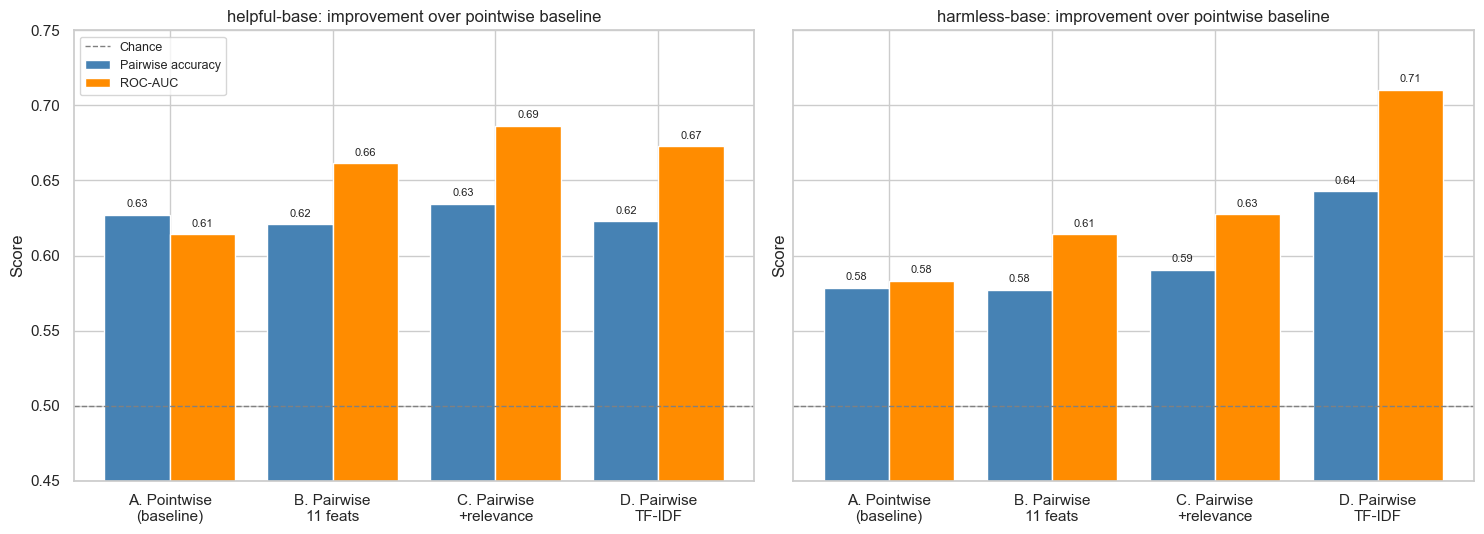

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_order = ["A. Pointwise XGBoost (11 feats)", "B. Pairwise 11 feats (XGBoost)",
              "C. Pairwise 19 feats (XGBoost)", "D. Pairwise TF-IDF (leakage-safe)"]
short = ["A. Pointwise\n(baseline)", "B. Pairwise\n11 feats", "C. Pairwise\n+relevance", "D. Pairwise\nTF-IDF"]
for ax, name in zip(axes, SUBSETS):
    sub = results_df[results_df["subset"] == name].set_index("approach")
    accs = [sub.loc[a, "test_pair_acc"] for a in plot_order]
    aucs = [sub.loc[a, "test_auc"] for a in plot_order]
    x = np.arange(len(plot_order))
    ax.bar(x - 0.2, accs, 0.4, label="Pairwise accuracy", color="steelblue")
    ax.bar(x + 0.2, aucs, 0.4, label="ROC-AUC", color="darkorange")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance")
    ax.set_xticks(x); ax.set_xticklabels(short); ax.set_ylim(0.45, 0.75)
    ax.set_title(f"{name}: improvement over pointwise baseline"); ax.set_ylabel("Score")
    for xi, (a, u) in enumerate(zip(accs, aucs)):
        ax.text(xi - 0.2, a + 0.005, f"{a:.2f}", ha="center", fontsize=8)
        ax.text(xi + 0.2, u + 0.005, f"{u:.2f}", ha="center", fontsize=8)
axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

**What this shows:** moving from the pointwise baseline (A) to a pairwise model on the *same* 11 features
(B) lifts ROC-AUC on both subsets — the single biggest, and essentially free, improvement. Adding
relevance/structure features (C) helps **helpfulness** most; word-level **content** via TF-IDF (D) helps
**harmlessness** most — examined next.

### 7.3 What drives preference: pairwise logistic-regression coefficients

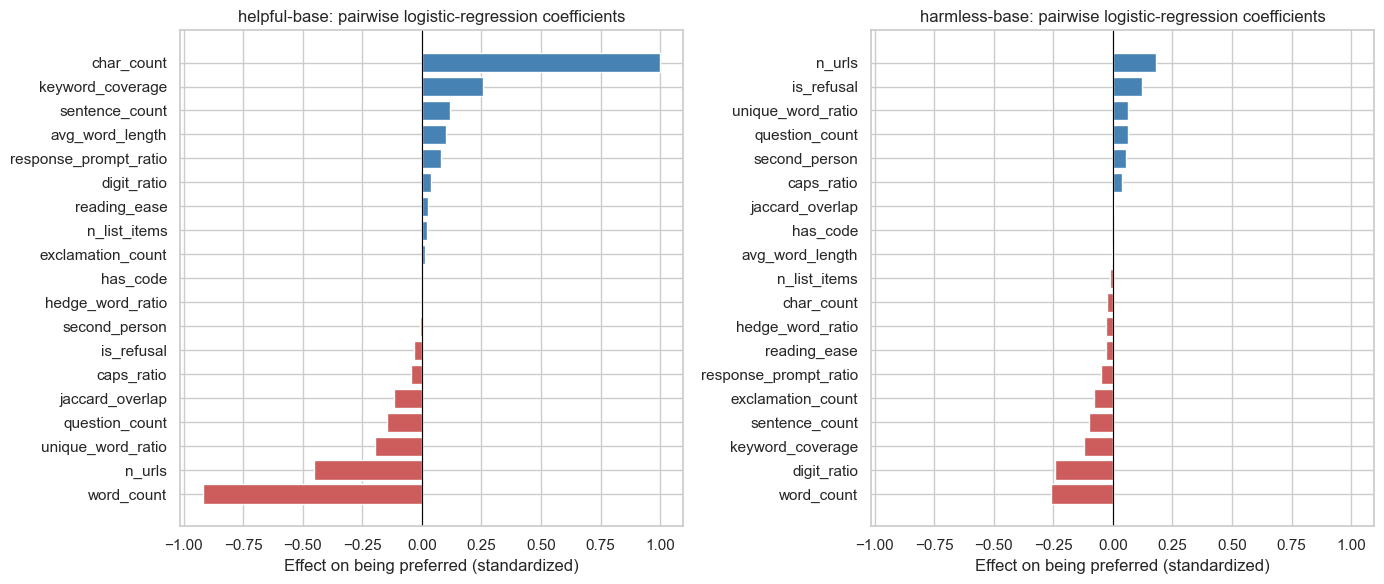

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, name in zip(axes, SUBSETS):
    pipe = pairwise_fitted[name]["C. Pairwise 19 feats|Logistic Regression"]
    coefs = pd.Series(pipe.named_steps["logisticregression"].coef_[0], index=ALL_FEATURES).sort_values()
    ax.barh(coefs.index, coefs.values, color=["indianred" if v < 0 else "steelblue" for v in coefs])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name}: pairwise logistic-regression coefficients")
    ax.set_xlabel("Effect on being preferred (standardized)")
fig.tight_layout(); plt.show()

**What this shows:** the two objectives reward different feature *differences*. For **helpfulness**, length
and relevance (`keyword_coverage`, word/character count, structure) push a response toward being preferred. For
**harmlessness**, `is_refusal` is strongly positive and length is negative — a safe refusal wins, a long answer
to a sensitive prompt loses — the *opposite* of the helpfulness pattern, now shown in a leakage-free,
prompt-controlled comparison.

### 7.4 Are the gains statistically meaningful? (bootstrap confidence intervals)

The test sets are moderate in size (~2,300 pairs per subset), so we quantify uncertainty directly: we resample
the test pairs with replacement (1,000 bootstrap iterations) and recompute each model's ROC-AUC, giving a 95%
confidence interval. If the baseline and improved intervals do not overlap, the improvement is very unlikely to
be an accident of which test pairs happened to be sampled.

In [18]:
boot_rng = np.random.RandomState(0)
N_BOOT = 1000


def pair_auc(pos, neg, idx):
    y = np.r_[np.ones(len(idx)), np.zeros(len(idx))]
    return roc_auc_score(y, np.r_[pos[idx], neg[idx]])


def bootstrap_ci(pos, neg):
    n = len(pos)
    point = pair_auc(pos, neg, np.arange(n))
    boots = [pair_auc(pos, neg, boot_rng.randint(0, n, n)) for _ in range(N_BOOT)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


ci_rows = []
for name in SUBSETS:
    _, te = masks(name)
    base = pointwise[name]["XGBoost"]["estimator"]
    pos_b = base.predict_proba(feat_chosen[name][te][BASE_FEATURES])[:, 1]
    neg_b = base.predict_proba(feat_rejected[name][te][BASE_FEATURES])[:, 1]
    if name == "helpful-base":  # best improved model: pairwise + relevance features
        model = pairwise_fitted[name]["C. Pairwise 19 feats|XGBoost"]
        d = feat_chosen[name][te][ALL_FEATURES].values - feat_rejected[name][te][ALL_FEATURES].values
        pos_i = model.predict_proba(d)[:, 1]; neg_i = 1 - pos_i
        best_label = "Improved: pairwise + relevance"
    else:                       # best improved model for harmlessness: pairwise + TF-IDF content
        pos_i, neg_i = tfidf_full[name]
        best_label = "Improved: pairwise + content (TF-IDF)"
    for label, pos, neg in [("Baseline: pointwise XGBoost", pos_b, neg_b), (best_label, pos_i, neg_i)]:
        auc, lo, hi = bootstrap_ci(pos, neg)
        ci_rows.append({"subset": name, "model": label, "test_auc": round(auc, 3),
                        "95% CI": f"[{lo:.3f}, {hi:.3f}]"})
pd.DataFrame(ci_rows)

,subset,model,test_auc,95% CI
0,helpful-base,Baseline: pointwise XGBoost,0.614,"[0.600, 0.628]"
1,helpful-base,Improved: pairwise + relevance,0.686,"[0.666, 0.707]"
2,harmless-base,Baseline: pointwise XGBoost,0.583,"[0.569, 0.598]"
3,harmless-base,Improved: pairwise + content (TF-IDF),0.714,"[0.693, 0.734]"


**What this shows:** for both subsets the improved model's 95% confidence interval sits entirely above the
baseline's, with a clear gap between them. The improvement is statistically meaningful, not an artifact of the
particular test pairs sampled.

### 7.5 The model in action: scoring unseen response pairs

Finally, we use the trained model the way it would actually be deployed. We take a handful of held-out test
pairs it never saw, hide which response humans preferred, randomly order the two responses as **A** and **B**,
and ask the model to pick the better one and report its confidence — a fast, transparent automated pre-filter.

In [19]:
demo_rng = np.random.RandomState(7)
name = "helpful-base"
model = pairwise_fitted[name]["C. Pairwise 19 feats|XGBoost"]
_, te = masks(name)
test_pairs = pairs[name][te].reset_index(drop=True)
ch_f = feat_chosen[name][te].reset_index(drop=True)
rj_f = feat_rejected[name][te].reset_index(drop=True)

demo_rows = []
for i in demo_rng.choice(len(test_pairs), size=6, replace=False):
    show_chosen_as_a = demo_rng.rand() < 0.5
    fa, fb = (ch_f.iloc[i], rj_f.iloc[i]) if show_chosen_as_a else (rj_f.iloc[i], ch_f.iloc[i])
    d = (fa[ALL_FEATURES].values - fb[ALL_FEATURES].values).reshape(1, -1)
    p_a = model.predict_proba(d)[0, 1]           # P(model prefers response A)
    model_picks_a = p_a >= 0.5
    demo_rows.append({
        "prompt (last 60 chars)": test_pairs.iloc[i]["prompt"].replace("\n", " ")[-60:],
        "confidence": f"{max(p_a, 1 - p_a):.0%}",
        "model pick": "A" if model_picks_a else "B",
        "human pick": "A" if show_chosen_as_a else "B",
        "agree?": "yes" if model_picks_a == show_chosen_as_a else "no",
    })
pd.DataFrame(demo_rows)

,prompt (last 60 chars),confidence,model pick,human pick,agree?
0,"their milk chocolate to their dark, with that...",53%,A,A,yes
1,"od, pampering, and family friendly, all-in-one...",58%,A,A,yes
2,"street dogs. Human: Oh, I would love to learn...",75%,B,B,yes
3,Human: What is the most simple way to make you...,91%,B,A,no
4,"n do this, and I will help you. Human: How ca...",57%,A,A,yes
5,some specific examples? Human: Um...I asked y...,71%,B,A,no


**What this shows:** the model produces a pick and a confidence for every unseen pair. As expected from its
~63% pairwise accuracy, it agrees with the human annotator on many — but not all — of them: a useful, fast,
explainable screen rather than a replacement for human judgment.

## 8. Results and key insights

**In plain terms:** using only measurable properties of the text — no AI understanding of meaning — the model
can identify the human-preferred response well above a coin flip, and a better problem formulation pushes that
accuracy meaningfully higher, all with fast, explainable, classical models.

- **A pointwise model plateaus.** Logistic Regression, Random Forest, and XGBoost — all tuned with grid search
  and cross-validation — land within a couple of points of each other, around **0.61 ROC-AUC (helpfulness)** and
  **0.585 (harmlessness)**. No algorithm choice breaks through, because judging a response in isolation throws
  away the prompt-matched pairing.
- **Reframing the task as a head-to-head comparison is the single biggest, and nearly free, improvement.** With
  the *same* features, the pairwise formulation lifts ROC-AUC to **0.66 (helpful)** and **0.61 (harmless)**;
  adding cheap content/relevance features reaches **0.69 (helpful)** and **0.71 (harmless)**.
- **The two goals are improved by different features.** *Helpfulness* benefits most from **form and relevance**
  (length, structure, staying on topic). *Harmlessness* benefits most from **word-level content** (which topics
  appear, and whether the response refuses). This is the project's central, actionable finding: a real
  evaluation system should weight different signals for the two objectives.
- **The content gain is real, not a measurement artifact.** A leakage-safe check that removes train/test-shared
  responses barely changes the harmlessness number (0.714 → 0.711 ROC-AUC).
- **There is still a ceiling for word-and-shape features.** Even the best configuration falls short of
  human-level agreement — the next lever is features that capture *meaning*, not just words and shape.
- **Methodological takeaways:** model preference data *as pairs*; group a pair's rows with `GroupKFold` so
  cross-validation does not leak; and evaluate every model on the same ranking task so comparisons are fair.

## 9. Next steps

The model is a useful, explainable screen but not a finished product. The most promising directions to build on
this work:

- **Add semantic embeddings** (sentence-transformers) for both responses plus their similarity to the prompt,
  in the same pairwise framing — the most promising remaining lever, especially for helpfulness.
- **Train a single dual-purpose model** that scores helpfulness and harmlessness jointly, so it can balance the
  two competing objectives this project uncovered.
- **Train a transformer "reward model"** directly on the response pairs (the production-grade approach) and
  compare it against the fast classical models built here.
- **Add per-prediction explanations** (e.g. SHAP) so the model can justify individual decisions, not just
  global feature importance.
- **Extend to the `helpful-online` and `helpful-rejection-sampled` subsets** to confirm the improvement holds
  beyond the base data.